<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml18_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN(Convolutional Neural Network, 합성곱 신경망)

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import convolve, convolve2d, correlate, correlate2d
from sklearn.datasets import load_sample_image, load_sample_images
from sklearn.metrics import confusion_matrix

import keras

# 합성곱 연산

같은 인덱스의 원소들끼리는 곱하고, 곱한 값들을 모두 더함.

## 1차원 배열 합성곱 연산(1D Convolution)

In [ ]:
x = np.arange(1, 5)
print(x)

[1 2 3 4]


In [ ]:
y = np.array([1, 2])
print(y)

[1 2]


In [ ]:
y_flip = np.flip(y)
print(y_flip)

[2 1]


### `convolve()` 함수

scipy 패키지의 convolve 함수는 배열 y를 반전(flip)시키고 합성곱 연산을 수행.

In [ ]:
# 'valid' 모드: 결과가 배열 x보다 크기가 줄어듦.
result = convolve(x, y, mode='valid')
print(result)

[ 4  7 10]


In [ ]:
# 'same' 모드: 결과가 배열 x의 크기와 같음.
result = convolve(x, y, mode='same')
print(result)

[ 1  4  7 10]


In [ ]:
# 'full' 모드: 배열 x의 모든 원소들이 합성곱 연산에서 같은 비율(횟수)로 참여하도록 패딩을 넣고 연산을 수행.
result = convolve(x, y, mode='full')
print(result)

[ 1  4  7 10  8]


### `correlate()` 함수

교차상관(cross-corrleate): 배열 y를 반전시키지 않고 합성곱 연산을 수행.

In [ ]:
result = correlate(x, y, mode='valid')
print(result)

[ 5  8 11]


In [ ]:
result = correlate(x, y, mode='same')
print(result)

[ 2  5  8 11]


In [ ]:
result = correlate(x, y, mode='full')
print(result)

[ 2  5  8 11  4]


## 2차원 배열 합성곱(2D Convolution)

In [ ]:
x = np.arange(1, 17).reshape((4, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [ ]:
y = np.array([[0, 1],
              [2, 0]])
print(y)

[[0 1]
 [2 0]]


In [ ]:
y_flip = np.flip(y)
print(y_flip)

[[0 2]
 [1 0]]


### `convolve2d()` 함수

In [ ]:
result = convolve2d(x, y, mode='valid')
print(result)

[[ 9 12 15]
 [21 24 27]
 [33 36 39]]


In [ ]:
result = convolve2d(x, y, mode='same')
print(result)

[[ 0  1  2  3]
 [ 2  9 12 15]
 [10 21 24 27]
 [18 33 36 39]]


In [ ]:
result = convolve2d(x, y, mode='full')
print(result)

[[ 0  1  2  3  4]
 [ 2  9 12 15  8]
 [10 21 24 27 12]
 [18 33 36 39 16]
 [26 28 30 32  0]]


### `correlate2d()` 함수

In [ ]:
result = correlate2d(x, y, mode='valid')
print(result)

[[12 15 18]
 [24 27 30]
 [36 39 42]]


In [ ]:
result = correlate2d(x, y, mode='same')
print(result)

[[12 15 18 16]
 [24 27 30 24]
 [36 39 42 32]
 [14 15 16  0]]


In [ ]:
result = correlate2d(x, y, mode='full')
print(result)

[[ 0  2  4  6  8]
 [ 1 12 15 18 16]
 [ 5 24 27 30 24]
 [ 9 36 39 42 32]
 [13 14 15 16  0]]


## 이미지 배열과 합성곱 연산

Python에서 이미지 파일을 다루는 방식

*   숫자들의 배열
    *   숫자들의 스케일
        *   0 ~ 255 정수 스케일
        *   0.0 ~ 1.0 실수 스케일
    *   배열의 모양
        *   흑백 이미지: (height, width) 모양의 2차원 배열
        *   컬러 이미지: (height, width, channel) 모양의 3차원 배열
            *   투명도가 없는 이미지: (height, width, 3). channel = red, green, blue
            *   투명도가 있는 이미지: (heigth, width, 4). channel = reg, green, blue, alpha
*   Keras 패키지에서는 합성곱 층에서 흑백 이미지를 사용할 때 컬러 이미지처럼 3차원 배열로 사용해야 함.
    *   Keras 패키지는 흑백 이미지를 (height, width, 1) 모양의 3차원 배열로 취급.


In [20]:
china = load_sample_image('china.jpg')
china.shape  #> jpg 파일을 읽어서 numpy 배열로 리턴

(427, 640, 3)

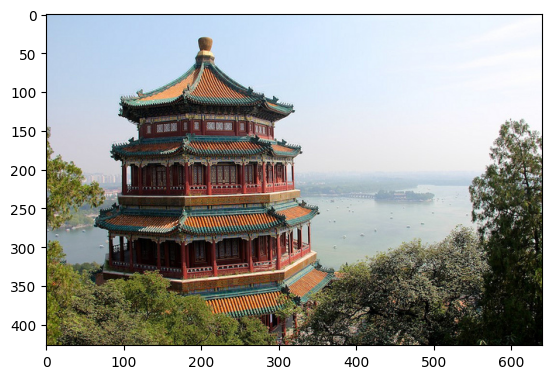

In [21]:
plt.imshow(china)
plt.show()

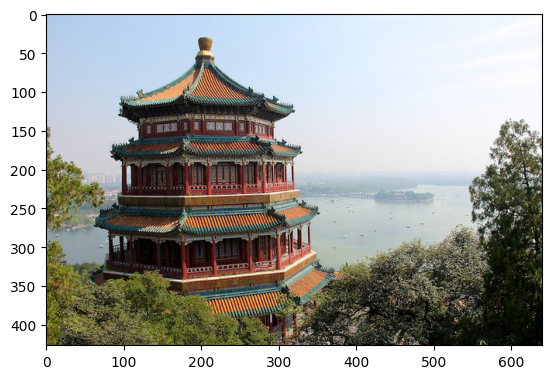

In [23]:
china_scaled = china / 255.0  # 0 ~ 255 정수 스케일을 0.0 ~ 1.0 실수 스케일로 변환
plt.imshow(china_scaled)
plt.show()

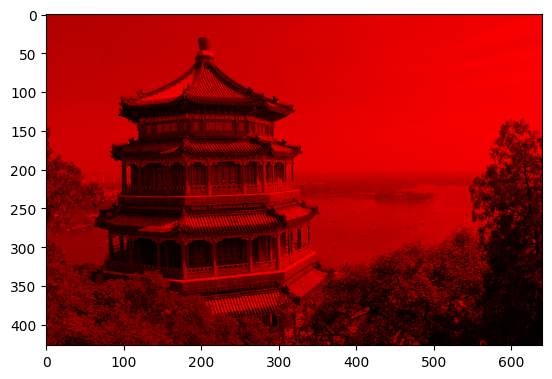

In [24]:
copy = china_scaled.copy()
copy[:, :, [1, 2]] = 0.0  # green, blue 색상을 모두 0으로. red 색상만 남김.
plt.imshow(copy)
plt.show()

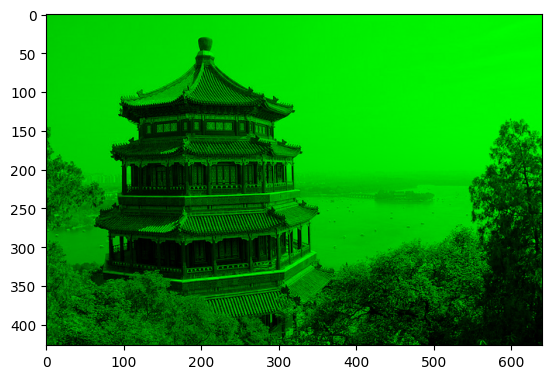

In [25]:
copy = china_scaled.copy()
copy[:, :, [0, 2]] = 0.0  # red, blue 색상을 모두 0으로. green 색상만 남김.
plt.imshow(copy)
plt.show()

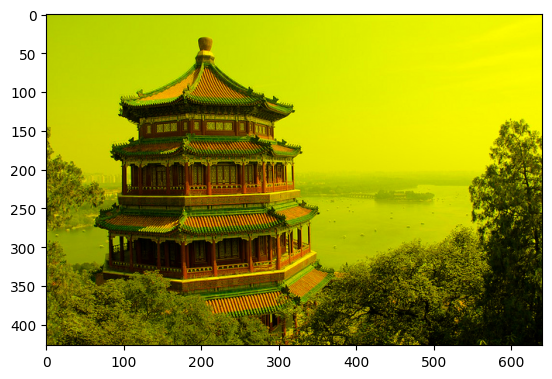

In [26]:
copy = china_scaled.copy()
copy[:, :, 2] = 0.0  # blue 색상만 제거.
plt.imshow(copy)
plt.show()

In [27]:
filter = np.zeros(shape=(3, 3, 3))
filter[:, :, 0] = 1
result = convolve(china, filter, mode='same')
result = result.astype(np.uint8)  # uint8: 8 bits unsigned integer(8bits=1byte 부호 없는 정수)
print(result.shape)

(427, 640, 3)


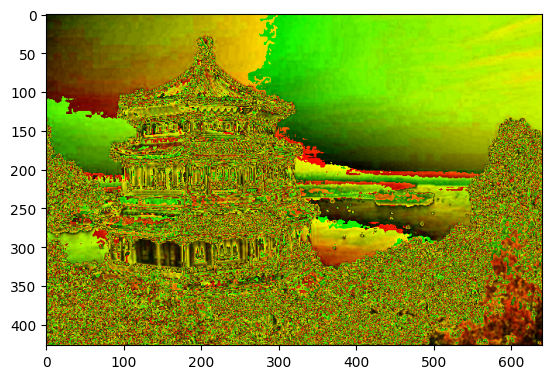

In [28]:
plt.imshow(result)
plt.show()

# Pooling

In [29]:
x = np.arange(1, 21).reshape((5, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]


In [40]:
(3+4+7+8)/4

5.5

In [31]:
# Keras의 Pooling 연산 클래스는 입력값으로 (n_samples, height, width, channel) 형식의 4차원 배열을 사용.
x_4d = x.reshape((1, 5, 4, 1))
print(x_4d)

[[[[ 1]
   [ 2]
   [ 3]
   [ 4]]

  [[ 5]
   [ 6]
   [ 7]
   [ 8]]

  [[ 9]
   [10]
   [11]
   [12]]

  [[13]
   [14]
   [15]
   [16]]

  [[17]
   [18]
   [19]
   [20]]]]


## Max Pooling(최대 풀링)

필터링된 값들 중에서 최댓값을 선택하는 풀링 방식

In [33]:
max_pooling = keras.layers.MaxPool2D()  # 2D max pooling 연산을 수행하는 객체
result = max_pooling(x_4d)  # max pooling 연산 수행
print(type(result))  #> type: Tensor(다차원 배열)
print(result.shape)  #> (1, 2, 2, 1) = (n_samples, height, width, channel)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [34]:
result.numpy().reshape((2, 2))  # Tensor --> numpy 배열 --> 2차원 모양으로 변환

array([[ 6,  8],
       [14, 16]])

## Average Pooling(평균 풀링)

필터링된 값들의 평균값을 선택하는 풀링 방식.

In [37]:
# TensorFlow는 암무적인 타입 변환을 수행하지 않음.(정수는 정수끼리만, 실수는 실수끼리만 연산)
x = x.astype(np.float32)  # 숫자 타입을 32bits(= 4bytes) 실수 타입으로 변환.
x_4d = x.reshape((1, 5, 4, 1))
avg_pooling = keras.layers.AveragePooling2D(pool_size=(2, 2))  # 2D 평균 풀링을 수행하는 객체
result = avg_pooling(x_4d)
print(type(result))
print(result.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [38]:
result.numpy().reshape((2, 2))

array([[ 3.5,  5.5],
       [11.5, 13.5]], dtype=float32)